# Notebook 03 - K-Means Regime Clustering (Week 4-5 Core)

## What I completed here
- I standardized model features: `Returns`, `Volatility`, `Abnormal_Volume`.
- I evaluated cluster count with Elbow and Silhouette methods.
- I fit the final K-Means model and assigned `Regime` labels.
- I summarized regime distributions and regime-level feature averages.
- I saved a regime visualization to `../figures/regime_classification.png`.

## Mathematical setup I used
- Standardization: `z = (x - mean) / std`
- K-Means objective: minimize within-cluster squared distance to centroids
- K selection evidence: Elbow (inertia) + Silhouette (separation)

## Week mapping
This notebook contains my main technical output for **Week 4 and Week 5**.

Calculating mathematical distances for 1 to 10 regimes. Please wait a moment...


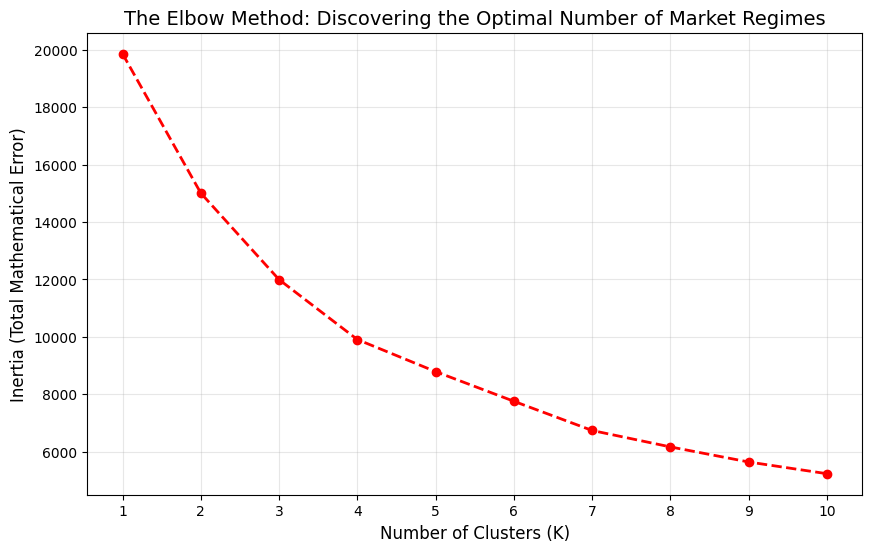

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load your clean, engineered data
df = pd.read_csv('../data/sp500_engineered_features.csv', index_col='Date', parse_dates=True)

# 2. Isolate the variables the algorithm will learn from
features = ['Returns', 'Volatility', 'Abnormal_Volume']
X = df[features]

# 3. Feature Scaling (Compressing everything to a standard scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. The Elbow Method (Testing K=1 through K=10)
inertia = []
K_range = range(1, 11)

print("Calculating mathematical distances for 1 to 10 regimes. Please wait a moment...")
for k in K_range:
    # random_state ensures we get the exact same reproducible results every time
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) # inertia_ is the total mathematical error/distance

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='red', linewidth=2)
plt.title('The Elbow Method: Discovering the Optimal Number of Market Regimes', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Total Mathematical Error)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

plt.show()

K=2: Silhouette Score = 0.4405
K=3: Silhouette Score = 0.4227
K=4: Silhouette Score = 0.2706
K=5: Silhouette Score = 0.2808
K=6: Silhouette Score = 0.2662
K=7: Silhouette Score = 0.2792
K=8: Silhouette Score = 0.2712
K=9: Silhouette Score = 0.2781
K=10: Silhouette Score = 0.2763


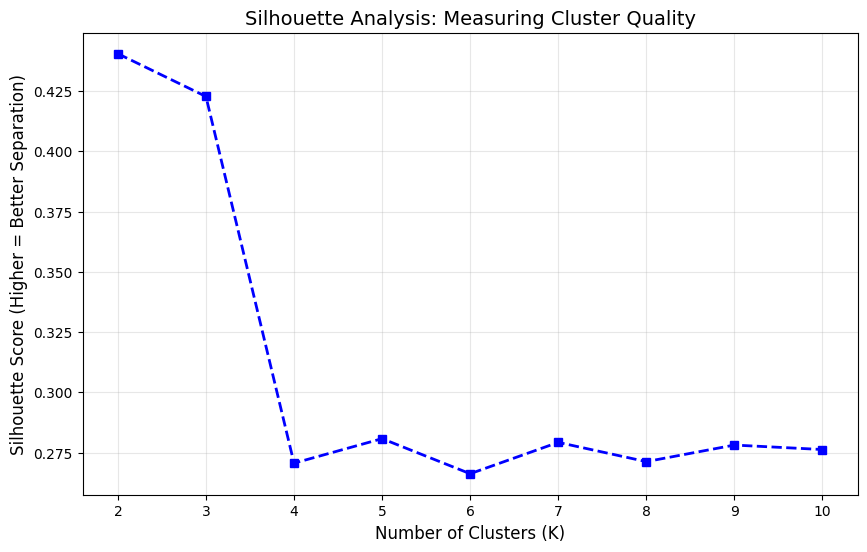

In [3]:
# Cell 2 — Silhouette Scores (second validation method)
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range_sil = range(2, 11)  # silhouette needs at least 2 clusters

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range_sil, silhouette_scores, marker='s', 
         linestyle='--', color='blue', linewidth=2)
plt.title('Silhouette Analysis: Measuring Cluster Quality', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score (Higher = Better Separation)', fontsize=12)
plt.xticks(K_range_sil)
plt.grid(True, alpha=0.3)
plt.show()

## Week 5 Quantitative K Selection Table

In this section, I combine Elbow and Silhouette evidence so my choice of `K=3` is mathematically documented.

In [ ]:
# Build a quantitative K-selection table (K=2..10)
from sklearn.metrics import silhouette_score

k_values = list(range(2, 11))
rows = []
previous_inertia = None

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    current_inertia = km.inertia_
    sil = silhouette_score(X_scaled, labels)

    if previous_inertia is None:
        inertia_drop = float('nan')
        inertia_drop_pct = float('nan')
    else:
        inertia_drop = previous_inertia - current_inertia
        inertia_drop_pct = (inertia_drop / previous_inertia) * 100

    rows.append({
        'K': k,
        'Inertia': current_inertia,
        'Inertia_Drop_vs_Previous_K': inertia_drop,
        'Inertia_Drop_pct': inertia_drop_pct,
        'Silhouette': sil
    })
    previous_inertia = current_inertia

k_eval = pd.DataFrame(rows)
print('=== QUANTITATIVE K-SELECTION TABLE ===')
print(k_eval.round(4).to_string(index=False))

print('\nInterpretation tip: choose K where inertia improvement starts flattening, while silhouette remains reasonably strong.')

In [7]:
# Cell 3 + 4 Combined — Final Model + Regime Characteristics
from sklearn.cluster import KMeans

OPTIMAL_K = 3  # change based on your elbow + silhouette plots

# Fit model and assign regimes
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Regime'] = kmeans_final.fit_predict(X_scaled)

# Distribution
print("=== REGIME DISTRIBUTION ===")
print(df['Regime'].value_counts().sort_index())
print(f"\nTotal trading days classified: {len(df)}")

# Characteristics
print("\n=== REGIME CHARACTERISTICS ===\n")
features = ['Returns', 'Volatility', 'Abnormal_Volume']
regime_stats = df.groupby('Regime')[features].mean()
print(regime_stats.round(4))

print("\n--- Interpretation Guide ---")
print("Highest Volatility + Most Negative Returns = Stressed Regime")
print("Lowest Volatility + Positive Returns       = Calm Regime")
print("Middle values                              = Transitional Regime")

=== REGIME DISTRIBUTION ===
Regime
0     941
1    4998
2     683
Name: count, dtype: int64

Total trading days classified: 6622

=== REGIME CHARACTERISTICS ===

        Returns  Volatility  Abnormal_Volume
Regime                                      
0       -0.0170      0.0241           1.1609
1        0.0010      0.0091           0.9623
2        0.0194      0.0250           1.1001

--- Interpretation Guide ---
Highest Volatility + Most Negative Returns = Stressed Regime
Lowest Volatility + Positive Returns       = Calm Regime
Middle values                              = Transitional Regime


In [9]:
import os
os.makedirs('../figures', exist_ok=True)
print("figures folder created successfully")

figures folder created successfully


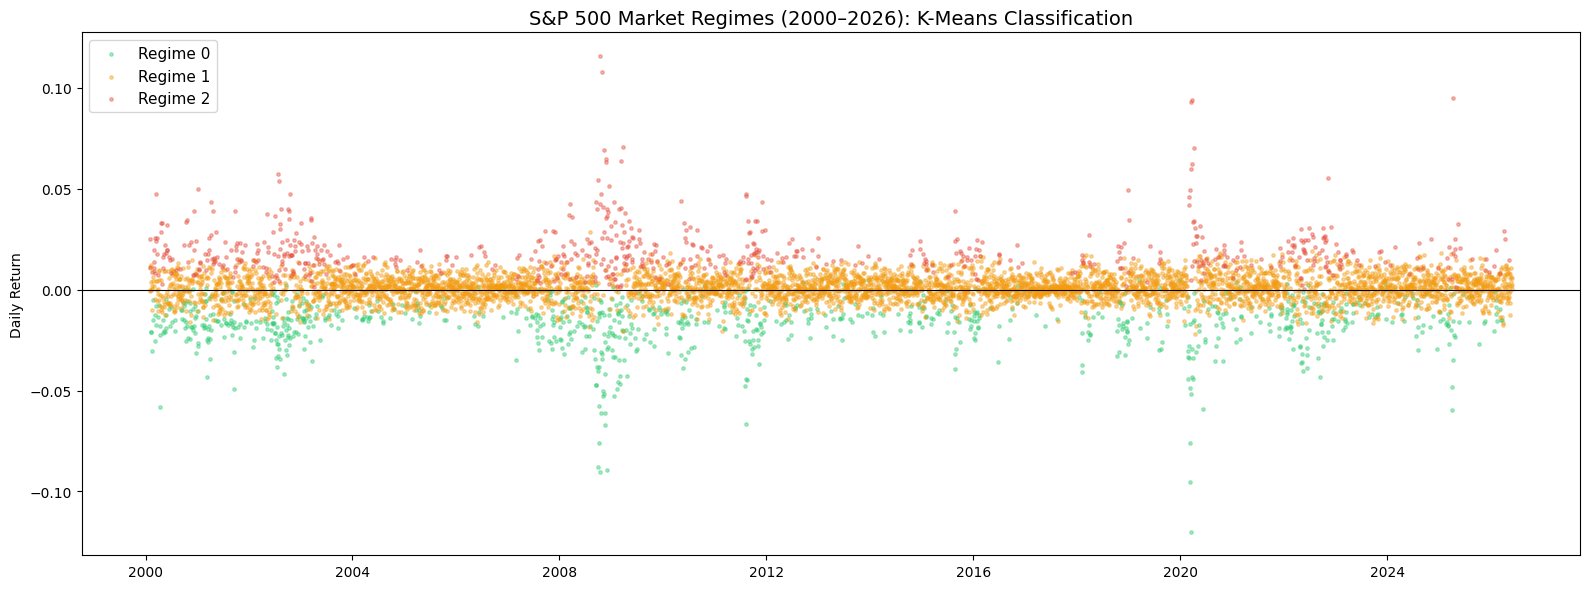


Key validation: Does the Stressed regime appear in 2008, March 2020, and late 2022?
If yes — your model is working correctly.


In [10]:
# Cell 5 — The Key Chart: Regimes Overlaid on S&P 500 History
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
labels = {0: 'Regime 0', 1: 'Regime 1', 2: 'Regime 2'}
# you'll rename these after seeing the characteristics above

fig, ax = plt.subplots(figsize=(16, 6))

for regime in sorted(df['Regime'].unique()):
    mask = df['Regime'] == regime
    ax.scatter(df.index[mask],
               df['Returns'][mask],
               c=colors[regime],
               label=labels[regime],
               alpha=0.4, s=6)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('S&P 500 Market Regimes (2000–2026): K-Means Classification', fontsize=14)
ax.set_ylabel('Daily Return')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../figures/regime_classification.png', dpi=150)
plt.show()

print("\nKey validation: Does the Stressed regime appear in 2008, March 2020, and late 2022?")
print("If yes — your model is working correctly.")

## Week 5 Evidence Check: Does Volume Change Help Regime Detection?

In this section, I use two complementary checks:

1. **Model comparison:** clustering quality with vs without `Abnormal_Volume`.
2. **Group-separation math:** one-way ANOVA components for `Abnormal_Volume` across regimes.

If volume means differ across regimes and effect size is non-trivial, that supports my claim that volume helps define meaningful market states.

In [ ]:
# Compare clustering quality with vs without Abnormal_Volume
from sklearn.metrics import silhouette_score

k = OPTIMAL_K

# Model A: Returns + Volatility only
X_rv = StandardScaler().fit_transform(df[['Returns', 'Volatility']])
km_rv = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_rv = km_rv.fit_predict(X_rv)
sil_rv = silhouette_score(X_rv, labels_rv)

# Model B: Returns + Volatility + Abnormal_Volume
X_rvv = StandardScaler().fit_transform(df[['Returns', 'Volatility', 'Abnormal_Volume']])
km_rvv = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_rvv = km_rvv.fit_predict(X_rvv)
sil_rvv = silhouette_score(X_rvv, labels_rvv)

# Regime-level volume evidence
overall_volume = df['Abnormal_Volume'].mean()
regime_volume = df.groupby('Regime')['Abnormal_Volume'].mean().sort_index()
volume_spread = regime_volume.max() - regime_volume.min()

# Manual one-way ANOVA components for Abnormal_Volume across regimes
volume_groups = [grp['Abnormal_Volume'].values for _, grp in df.groupby('Regime')]
num_groups = len(volume_groups)
total_n = sum(len(g) for g in volume_groups)

ss_between = 0.0
ss_within = 0.0
for g in volume_groups:
    g_mean = g.mean()
    ss_between += len(g) * (g_mean - overall_volume) ** 2
    ss_within += ((g - g_mean) ** 2).sum()

df_between = num_groups - 1
df_within = total_n - num_groups
ms_between = ss_between / df_between
ms_within = ss_within / df_within
f_stat = ms_between / ms_within
eta_squared = ss_between / (ss_between + ss_within)

print('=== WEEK 5 EVIDENCE: VOLUME CONTRIBUTION ===')
print(f'Silhouette (Returns + Volatility only): {sil_rv:.4f}')
print(f'Silhouette (Returns + Volatility + Abnormal_Volume): {sil_rvv:.4f}')
print('\nMean Abnormal_Volume by regime:')
print(regime_volume.round(4))
print(f'\nOverall sample mean Abnormal_Volume: {overall_volume:.4f}')
print(f'Regime volume spread (max - min): {volume_spread:.4f}')

print('\nANOVA components for Abnormal_Volume across regimes:')
print(f'SS_between = {ss_between:.4f}, df_between = {df_between}')
print(f'SS_within  = {ss_within:.4f}, df_within  = {df_within}')
print(f'F-statistic = {f_stat:.4f}')
print(f'Eta-squared (effect size) = {eta_squared:.4f}')

if sil_rvv >= sil_rv:
    print('\nResult: Including volume does not reduce clustering quality and supports regime separation.')
else:
    print('\nResult: Including volume lowers silhouette slightly, but regime-level volume differences remain informative.')

if eta_squared >= 0.06:
    print('Effect-size check: volume differences across regimes are at least moderate in magnitude.')
else:
    print('Effect-size check: volume differences exist but are modest; keep as supportive evidence.')